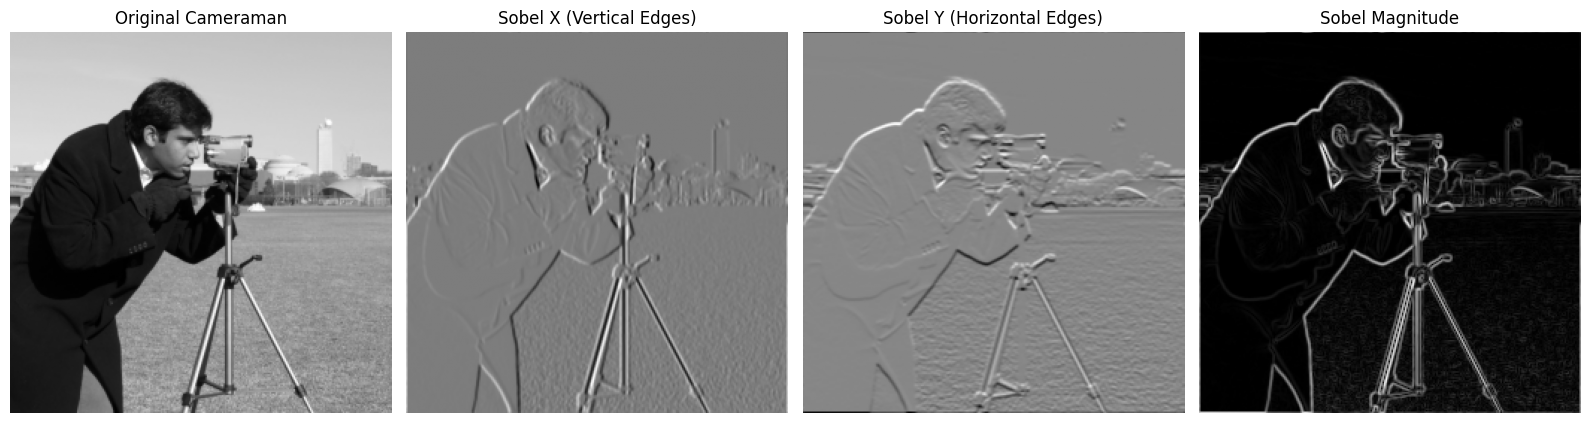

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, ifftshift

image = data.camera()
image = resize(image, (256, 256))
M, N = image.shape

sobel_x = np.array([[-1,  0,  1],
                    [-2,  0,  2],
                    [-1,  0,  1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    cy, cx = ph // 2, pw // 2
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    return fft2(ifftshift(padded))

F_image = fft2(image)

H_sobel_x = center_embed_kernel(sobel_x, (M, N))
H_sobel_y = center_embed_kernel(sobel_y, (M, N))

F_out_x = F_image * H_sobel_x
F_out_y = F_image * H_sobel_y

out_x = ifft2(F_out_x).real
out_y = ifft2(F_out_y).real

sobel_magnitude = np.sqrt(out_x**2 + out_y**2)

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(out_x, cmap='gray')
plt.title('Sobel X (Vertical Edges)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(out_y, cmap='gray')
plt.title('Sobel Y (Horizontal Edges)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()